# CBED Frame Simulation

Demonstrate how to simulate a CBED frame using this package, with pseudo-realistic and controllable quality.

In [1]:
%load_ext autoreload

In [2]:
%load_ext line_profiler

In [3]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import center_of_mass
from cbed_simulation.frame_builder import FrameParameters, xp, ndimage as xndimage
from cbed_simulation.crystal_orientation import OrientedPhase, ExperimentInformation
from orix.quaternion import Rotation

from scipy import ndimage

import sparseconverter as spc

We load a structure in a given orientation, this can be an `hkl` index or an `orix.quaternion.Rotation` object for an aribtrary Euler angle.

In [8]:
%autoreload
phase = OrientedPhase.from_cif("./Si.cif", orientation=Rotation.from_euler((0, 0, 0)))

In [9]:
Rotation.from_euler((0, 0, 0))

Rotation (1,)
[[ 1. -0. -0. -0.]]

In [10]:
phase.with_rot(Rotation.from_euler((1, 1, 1)))

OrientedPhase(phase=<name: Si. space group: Fd-3m. point group: m-3m. proper point group: 432. color: tab:blue>, atoms=Atoms(symbols='Si8', pbc=True, cell=[5.4307, 5.4307, 5.4307], spacegroup_kinds=...), orientation=Rotation (1,)
[[ 0.4742 -0.4794 -0.     -0.7385]])

The `ExperimentInformation` sets the physical parameters of the simulation, notably the detector shape and the scale factor.

In [11]:
experiment = ExperimentInformation(
    frame_shape=(512, 512),
    radius_px=12,
    ellipse_minor=None,
    ellipse_orientation=45,
    transmitted_centre_px=complex(256, 256),
    pattern_scale_factor=120.,  # pixels / Å-1
)

The `FrameParameters` determine how the simulated peaks will be rendered to a frame, mainly the strength of noise and blur.

In [12]:
frame_params = FrameParameters(
    disk_blur_sigma=0.5,
    intensity_from_radius=False,
    textured=False,
)

In [13]:
def make_frame(experiment, frame_params, stretch_abc=(1., 1., 1.), scale_bc_ac_ab=(1., 1., 1.), rotate_deg=0., max_excitation_error=None, xp=xp, ndimage=xndimage):
    sim_peaks = phase.peak_positions(
        experiment,
        #stretch_abc=stretch_abc,
        #scale_bc_ac_ab=scale_bc_ac_ab,
        rotate_deg=rotate_deg,
        max_excitation_error=max_excitation_error,
        bloch=False,
        xp=xp
    )
    # Play with the intensities to make the transmitted beam more similar to the diffracted beams
    sim_peaks.modify_intensities(power=0.25)
    sim_peaks.modify_000_intensity(multiply=2)
    return phase.synthetic(experiment, sim_peaks, frame_params=frame_params, xp=xp, ndimage=ndimage), sim_peaks

In [14]:
from abtem.bloch import BlochWaves, StructureFactor

In [15]:
%autoreload
frame_vacuum, _ = make_frame(experiment, frame_params, max_excitation_error=1e-5, xp=xp, ndimage=xndimage)  # tiny excitation error means only central spot is retained

Create an image of the transmitted beam only for later use:

In [16]:
%autoreload
%time frame_vacuum, _ = make_frame(experiment, frame_params, max_excitation_error=1e-5, xp=xp, ndimage=xndimage)  # tiny excitation error means only central spot is retained

CPU times: user 277 ms, sys: 1.31 s, total: 1.59 s
Wall time: 46.5 ms


In [17]:
frame_vacuum.dtype

dtype('int64')

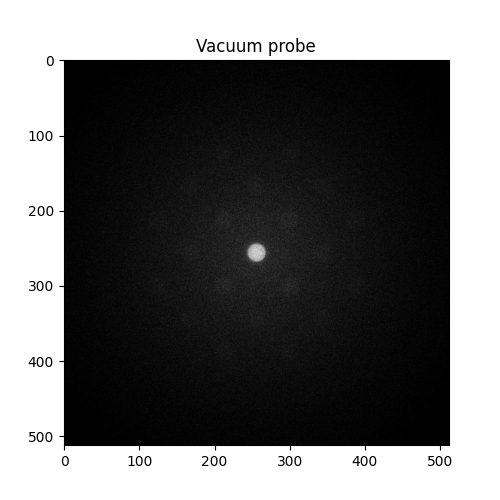

In [18]:
fig, ax1 = plt.subplots(1, 1, figsize=(5, 5))
ax1.imshow(spc.for_backend(frame_vacuum, spc.NUMPY), cmap="gray")
ax1.set_title("Vacuum probe");

Create a strained and unstrained diffraction pattern:

In [19]:
%autoreload
%time frame_unstrained, sim_peaks_unstrained = make_frame(experiment, frame_params)
stretch = (1., 1., 1)
bend = (1., 1., 1)
rotate = 0  # degrees
%time frame_strained, sim_peaks_strained = make_frame(experiment, frame_params, stretch_abc=stretch, scale_bc_ac_ab=bend, rotate_deg=rotate)

CPU times: user 364 ms, sys: 2.47 s, total: 2.84 s
Wall time: 71.1 ms
CPU times: user 500 ms, sys: 2.95 s, total: 3.45 s
Wall time: 72.1 ms


In [20]:
type(sim_peaks_strained)

cbed_simulation.crystal_orientation.SimulatedPeaks

In [21]:
frame_strained.shape

(512, 512)

In [22]:
import cbed_simulation.crystal_orientation
import cbed_simulation.frame_builder
import cbed_simulation.crystal_bloch

In [23]:
%lprun -f cbed_simulation.crystal_bloch.get_bloch_pattern -f cbed_simulation.frame_builder.build_frame -f cbed_simulation.frame_builder.gen_noise make_frame(experiment, frame_params, stretch_abc=stretch, scale_bc_ac_ab=bend, rotate_deg=rotate)

Timer unit: 1e-09 s

Total time: 0 s
File: /home/weber/src/cbed-simulation/src/cbed_simulation/crystal_bloch.py
Function: get_bloch_pattern at line 41

Line #      Hits         Time  Per Hit   % Time  Line Contents
    41                                           def get_bloch_pattern(
    42                                               cif_or_atoms: os.PathLike | Atoms,
    43                                               rotation: Rotation,
    44                                               stretch_abc: tuple[float, float, float] = (1., 1., 1.),
    45                                               scale_bc_ac_ab: tuple[float, float, float] = (1., 1., 1.),
    46                                               progress: bool = False,
    47                                               voltage: float = 200e3,
    48                                               thickness_nm: float = 200,
    49                                               max_extent: float = 2.,
    50              

Plot the peaks and the frames (hover over the point to see the miller index):

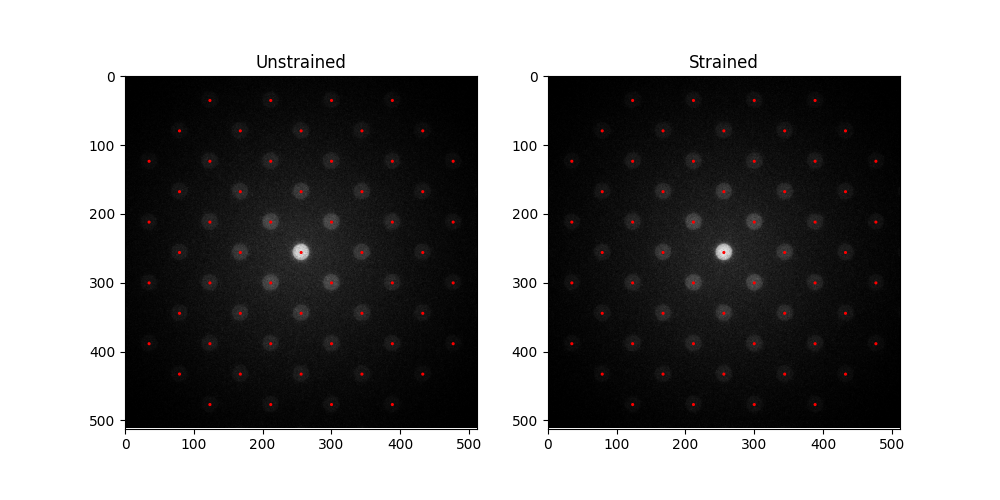

In [24]:
%autoreload
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(spc.for_backend(frame_unstrained, spc.NUMPY), cmap="gray")
ax1.set_title("Unstrained")
ax1.set_xlim(0, frame_unstrained.shape[1])
ax1.set_ylim(frame_unstrained.shape[0], 0)
sim_peaks_unstrained.to_pixels(experiment).plot(fig, ax1)
ax2.imshow(spc.for_backend(frame_strained, spc.NUMPY), cmap="gray")
ax2.set_title("Strained");
ax2.set_xlim(0, frame_unstrained.shape[1])
ax2.set_ylim(frame_unstrained.shape[0], 0)
sim_peaks_strained.to_pixels(experiment).plot(fig, ax2)

In [25]:
from cbed_simulation.udf import CBEDSimUDF
from libertem.api import Context

In [26]:
ctx = Context.make_with(gpus=4)
#ctx = Context.make_with(cpus=1)

In [27]:
data = np.random.uniform(low=0., high=2*np.pi, size=(16, 16, 3))
ds = ctx.load('memory', data=data, sig_dims=1, num_partitions=16)
assert tuple(ds.shape.sig) == (3, )

In [28]:
fname = 'tmp.npy'

In [29]:
udf = CBEDSimUDF(
    filename=fname,
    experiment=experiment,
    phase=phase,
    frame_params=frame_params,
)

In [30]:
res = ctx.run_udf(dataset=ds, udf=udf, progress=True)

Partitions 0/16, Frames:   0%|          | 0/256 [00:00<?, ?it/s]

## Validate strain values

Compute strain value using template matching to check we are applying the right stretches. This uses `LiberTEM` because it's quite compact to run template matching and lattice fitting, but you could use `py4DSTEM` here.

In [31]:
import libertem.api as lt
from libertem_blobfinder.common.correlation import get_peaks
from libertem_blobfinder.common.patterns import UserTemplate
from libertem_blobfinder.udf.correlation import FullFrameCorrelationUDF
from libertem_blobfinder.common.gridmatching import Matcher
from strain_mapping.strain_decomposition import compute_strain_large_def
from cbed_simulation.utils import to_complex, to_array

ctx = lt.Context.make_with("inline")


def match_template(ctx, frame, template, peaks):
    ds = ctx.load("memory", data=frame[np.newaxis, ...])
    udf = FullFrameCorrelationUDF(
        peaks=peaks.astype(int), match_pattern=template, zero_shift=None, upsample=20,
    )
    corr_result = ctx.run_udf(
        dataset=ds,
        udf=udf
    )
    positions = corr_result["refineds"].data.squeeze(axis=0)
    positions_int = corr_result["centers"].data.squeeze(axis=0)
    correlation_score = corr_result["peak_values"].data.squeeze(axis=0)
    return positions, positions_int, correlation_score

ModuleNotFoundError: No module named 'strain_mapping'

Extract a template from the vacuum frame:

In [ ]:
from cbed_simulation.template_from_image import template_from_vacuum

In [ ]:
cy, cx = to_array(experiment.transmitted_centre_px).astype(int)
rad = int(experiment.radius_px + max(experiment.radius_px * 1.5, 3))
template_frame = template_from_vacuum(frame_vacuum, (cy, cx), experiment.radius_px, beam_rescale_factor=1.)
template = template_frame[cy - rad: cy + rad, cx - rad: cx + rad]
template = UserTemplate(template)

In [ ]:
template_com = center_of_mass(template.template)
print(f"Template CoM: {template_com}, Template shape: {template.template.shape}, //2 {np.asarray(template.template.shape) // 2}")

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(10, 5))
ax1.imshow(frame_vacuum[cy - rad: cy + rad, cx - rad: cx + rad], cmap='gray')
ax1.set_title("Crop")
ax2.imshow(template.template, cmap='gray')
ax2.set_title("Template");

Find the peaks where we will run the template matching:

In [ ]:
num_peaks = 40
peaks_raw = get_peaks(frame_unstrained, template, num_peaks)

Run the template matching in the vicinity of the coarse peaks:

In [ ]:
positions_unstrained, positions_unstrained_int, score_unstrained = match_template(ctx, frame_unstrained, template, peaks_raw)
positions_strained, positions_strained_int, score_strained = match_template(ctx, frame_strained, template, peaks_raw)

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(frame_unstrained, cmap='gray')
ax1.plot(positions_unstrained[:, 1], positions_unstrained[:, 0], 'ro')
ax1.plot(positions_strained[:, 1], positions_strained[:, 0], 'go', alpha=0.3)
ax2.imshow(frame_strained, cmap='gray')
ax2.plot(positions_strained[:, 1], positions_strained[:, 0], 'go')
ax2.plot(positions_unstrained[:, 1], positions_unstrained[:, 0], 'ro', alpha=0.3);

Fit lattice vectors `a, b` (`g1, g2`) to the found peaks

In [ ]:
zero = sim_peaks_unstrained.to_pixels(experiment).spot_position((0, 0, 0))
vec_a = sim_peaks_unstrained.to_pixels(experiment).spot_position((0, 0, 2), centre_zero=True)
vec_b = sim_peaks_unstrained.to_pixels(experiment).spot_position((-1, 1, 1), centre_zero=True)
zero = to_array(zero)
vec_a = to_array(vec_a)
vec_b = to_array(vec_b)
match_unstrained = Matcher().fastmatch(positions_unstrained_int, zero, vec_a, vec_b, refineds=positions_unstrained, peak_values=score_unstrained)
match_strained = Matcher().fastmatch(positions_strained_int, zero, vec_a, vec_b, refineds=positions_strained, peak_values=score_strained)
match_strained.zero

Compute strain values based on these battice vectors:

In [ ]:
strain_res = compute_strain_large_def(
    to_complex(match_strained.a),
    to_complex(match_strained.b),
    to_complex(match_unstrained.a),
    to_complex(match_unstrained.b),
)
strain_res_rot = strain_res.to_vector(to_complex(match_strained.a))
strain_res_rot

In [ ]:
print(f"Computed e_xx: {strain_res_rot.e_xx * 100:.2f}%, Applied e_xx {(stretch[-1] - 1) * 100:.2f}%")

In [ ]:
print(f"Computed rotation: {strain_res_rot.theta_deg:.1f}°, Applied rotation {rotate:.1f}°")